In [1]:
import pandas as pd
import utils as uti

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path
import xgboost as xgb

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,55.250871,0.230883,False
1,credit_history_woe,29.540155,0.355625,True
2,savings_account_bonds_woe,23.821006,0.230883,False
3,duration_months_woe,21.980634,0.227627,False
4,credit_amount_woe,21.276853,0.146789,False


In [5]:
event = 'bad'

## make dummies

In [6]:
with open("../data/01_dic_feat_names.pkl", "rb") as file:
    feat_names = pickle.load(file)

In [7]:
X_raw= df[feat_names['raw']]
y = df[event]

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_columns = X_raw.select_dtypes(exclude="number").columns
numeric_columns = X_raw.select_dtypes(include="number").columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        ("numeric", "passthrough", numeric_columns)
    ]
)

In [9]:
train_array = preprocessor.fit_transform(X_raw)

# Apply the exact same dummy columns to the new dataset
# new_encoded = preprocessor.transform(new_df)

### save dummy encoder

In [10]:
type(preprocessor)

sklearn.compose._column_transformer.ColumnTransformer

In [11]:
import joblib

joblib.dump(preprocessor, "../data/02b_dummy_preprocessor.pkl")

['../data/02b_dummy_preprocessor.pkl']

### make into dataframe

In [12]:
# dont need to but make sit easier to look at if you need 

pre_names = preprocessor.get_feature_names_out()

# this is for later when we train on the entire set
X_oh_train = pd.DataFrame(
    train_array,
    columns=pre_names,
    index=df.index
)


In [13]:
# for optuna
X = df[feat_names['raw']]

## optimization

In [14]:
import numpy as np
import optuna
import toad
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def make_preprocessor(X_train):
    categorical_columns = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,  # Use sparse=True with older sklearn
                    dtype=np.float32
                ),
                categorical_columns
            ),
        ],
        remainder="passthrough",
        sparse_threshold=1.0
    )

    return preprocessor, categorical_columns, numeric_columns


def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "n_estimators": 3000,

        "max_depth": trial.suggest_int("max_depth", 2, 5),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.25, log=True
        ),

        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 30.0, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),

        "gamma": trial.suggest_float(
            "gamma", 1e-6, 5.0, log=True
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1.0, 100.0, log=True
        ),

        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 100,
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        # Fit binning only on the training fold
        combiner = toad.transform.Combiner()

        combiner.fit(
            X_fold_train,
            y=y_fold_train,
            method="chi",
            min_samples=0.05
        )

        X_fold_train_bins = combiner.transform(X_fold_train)
        X_fold_valid_bins = combiner.transform(X_fold_valid)

        # Identify object/category columns after binning
        preprocessor, _, _ = make_preprocessor(X_fold_train_bins)

        # Fit one-hot encoder only on the training fold
        X_fold_train_encoded = preprocessor.fit_transform(
            X_fold_train_bins
        )

        X_fold_valid_encoded = preprocessor.transform(
            X_fold_valid_bins
        )

        model = XGBClassifier(**params)

        model.fit(
            X_fold_train_encoded,
            y_fold_train,
            eval_set=[
                (X_fold_valid_encoded, y_fold_valid)
            ],
            verbose=False
        )

        valid_probabilities = model.predict_proba(
            X_fold_valid_encoded
        )[:, 1]

        fold_auc = roc_auc_score(
            y_fold_valid,
            valid_probabilities
        )

        fold_scores.append(fold_auc)

        trial.report(np.mean(fold_scores), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


In [15]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=250,
    show_progress_bar=True
)

[I 2026-09-11 18:22:19,601] A new study created in memory with name: no-name-c8f2cbfc-4adc-4703-a996-a4d16e6c4ae1


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-09-11 18:22:19,877] Trial 0 finished with value: 0.7860780423280425 and parameters: {'max_depth': 3, 'learning_rate': 0.2133249073808361, 'min_child_weight': 12.057126287443763, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 1.1091814877139725e-05, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 53.99484409787433}. Best is trial 0 with value: 0.7860780423280425.
[I 2026-09-11 18:22:20,250] Trial 1 finished with value: 0.78505291005291 and parameters: {'max_depth': 4, 'learning_rate': 0.09768839753070749, 'min_child_weight': 1.0725209743171995, 'subsample': 0.9909729556485982, 'colsample_bytree': 0.9497327922401265, 'gamma': 2.6451684446721577e-05, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 2.32706770838378}. Best is trial 0 with value: 0.7860780423280425.
[I 2026-09-11 18:22:20,503] Trial 2 finished with value: 0.7912698412698412 and parameters: {'max_depth': 3, 'learning_rate': 0.05414745020542119, 'min_child_weight': 4.345454109729

In [16]:
print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best AUC: 0.7968915343915344
Best parameters:
{'max_depth': 2, 'learning_rate': 0.08492702102608973, 'min_child_weight': 4.352161802006491, 'subsample': 0.7303461088934411, 'colsample_bytree': 0.8603270922635693, 'gamma': 2.586601436650844e-06, 'reg_alpha': 0.009582502426882505, 'reg_lambda': 8.105031437213981}


## optimization summary

In [17]:
import matplotlib.pyplot as plt

In [18]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_2408629/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


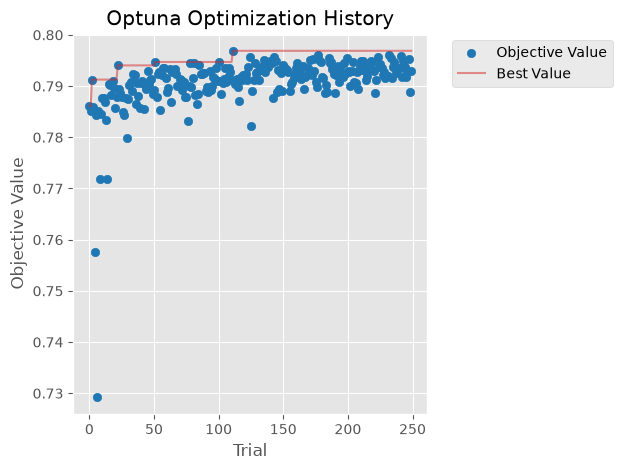

In [19]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408629/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


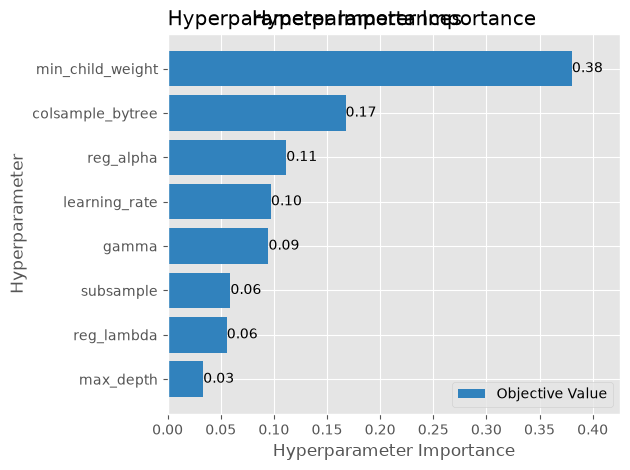

In [20]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408629/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_2408629/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


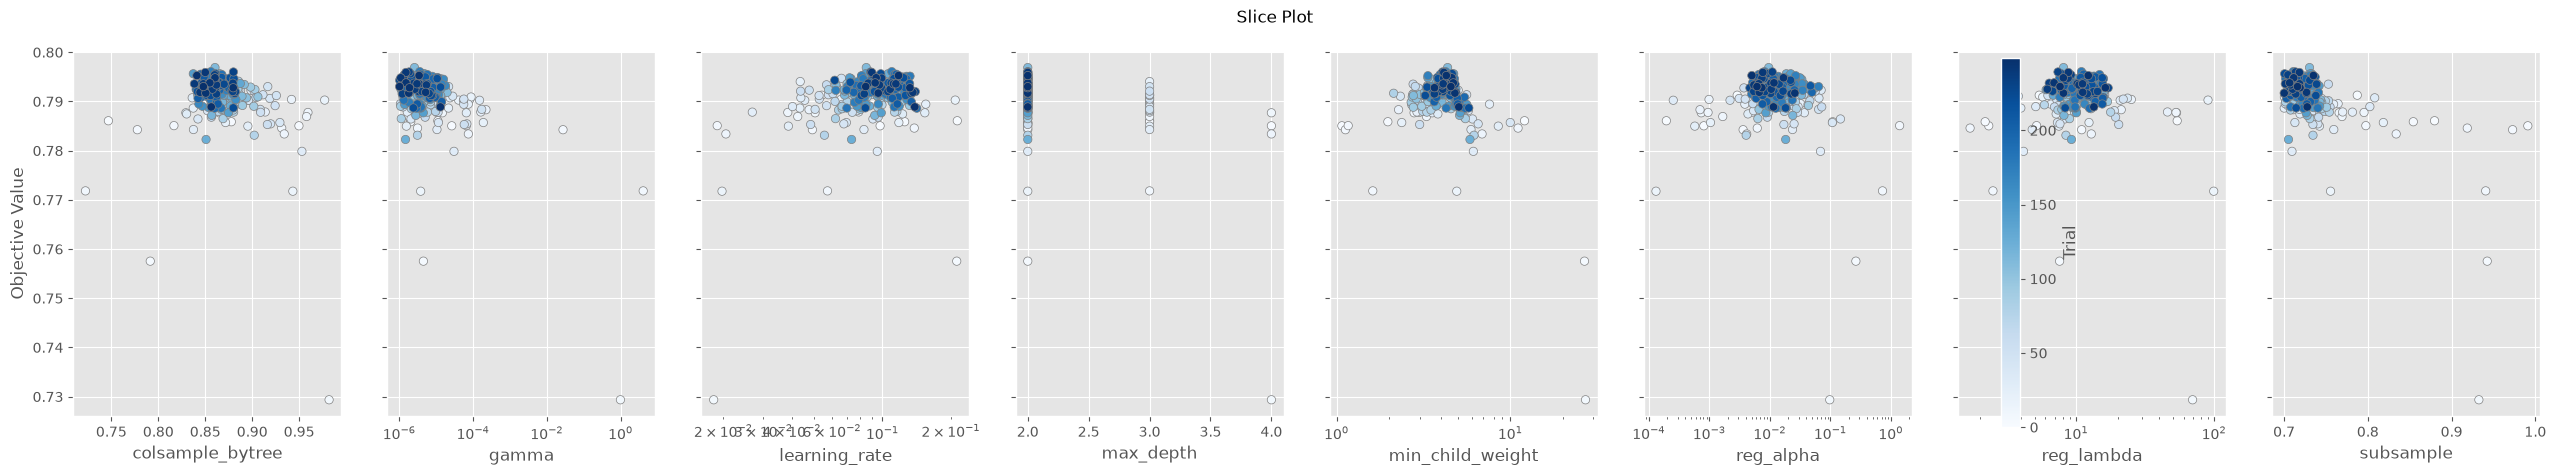

In [21]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408629/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


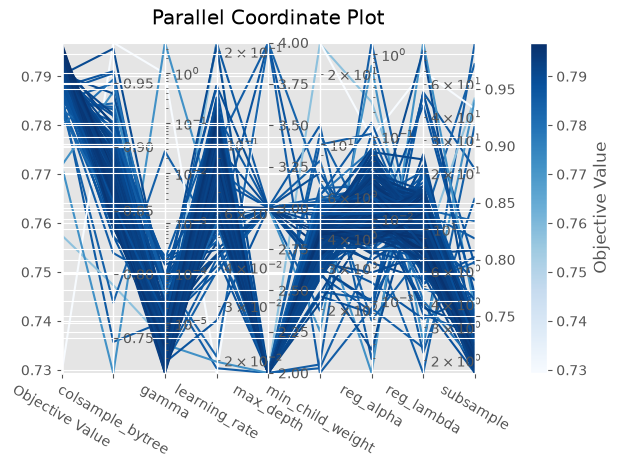

In [22]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2408629/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


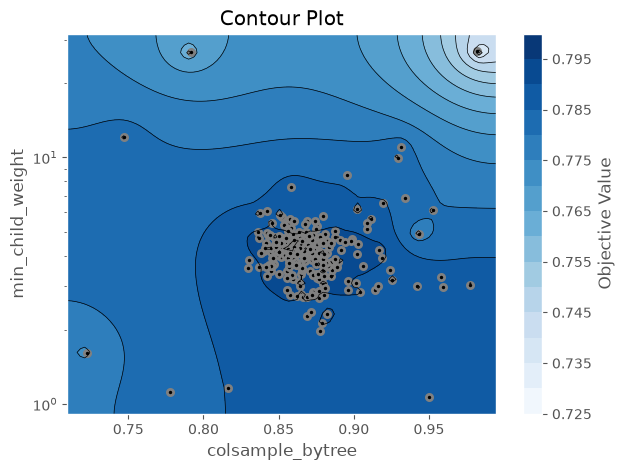

In [23]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [24]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [25]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
111,111,0.796892,2026-09-11 18:22:53.146701,2026-09-11 18:22:53.381526,0 days 00:00:00.234825,0.860327,0.000003,0.084927,2,4.352162,0.009583,8.105031,0.730346,"{""colsample_bytree"": 0.8603270922635693, ""gamm...",COMPLETE
177,177,0.796065,2026-09-11 18:23:12.835168,2026-09-11 18:23:13.071986,0 days 00:00:00.236818,0.855949,0.000004,0.109973,2,4.240669,0.008159,10.938037,0.710929,"{""colsample_bytree"": 0.8559494159120045, ""gamm...",COMPLETE
232,232,0.795999,2026-09-11 18:23:27.344423,2026-09-11 18:23:27.599453,0 days 00:00:00.255030,0.879939,0.000002,0.088791,2,4.072967,0.010968,7.389118,0.713700,"{""colsample_bytree"": 0.8799392429895104, ""gamm...",COMPLETE
241,241,0.795899,2026-09-11 18:23:29.564949,2026-09-11 18:23:29.816366,0 days 00:00:00.251417,0.850004,0.000002,0.089802,2,4.140772,0.007646,8.780106,0.718251,"{""colsample_bytree"": 0.8500040867084747, ""gamm...",COMPLETE
223,223,0.795635,2026-09-11 18:23:24.881060,2026-09-11 18:23:25.131699,0 days 00:00:00.250639,0.860853,0.000002,0.098312,2,4.617734,0.009023,7.807089,0.700647,"{""colsample_bytree"": 0.8608528969239054, ""gamm...",COMPLETE
124,124,0.795635,2026-09-11 18:22:56.544908,2026-09-11 18:22:56.786163,0 days 00:00:00.241255,0.865522,0.000004,0.105895,2,4.365956,0.018722,11.031953,0.732743,"{""colsample_bytree"": 0.8655223436741631, ""gamm...",COMPLETE
143,143,0.795635,2026-09-11 18:23:01.627293,2026-09-11 18:23:01.870704,0 days 00:00:00.243411,0.837230,0.000005,0.084374,2,4.718160,0.022137,8.902724,0.731235,"{""colsample_bytree"": 0.8372303233152883, ""gamm...",COMPLETE
199,199,0.795536,2026-09-11 18:23:18.650821,2026-09-11 18:23:18.876980,0 days 00:00:00.226159,0.845038,0.000004,0.115157,2,4.288118,0.007265,11.340885,0.709706,"{""colsample_bytree"": 0.8450384216534638, ""gamm...",COMPLETE
185,185,0.795470,2026-09-11 18:23:14.989327,2026-09-11 18:23:15.227751,0 days 00:00:00.238424,0.867593,0.000006,0.112969,2,3.942928,0.006557,14.783325,0.712251,"{""colsample_bytree"": 0.8675927420892398, ""gamm...",COMPLETE
233,233,0.795403,2026-09-11 18:23:27.600364,2026-09-11 18:23:27.843587,0 days 00:00:00.243223,0.859913,0.000001,0.091094,2,4.337455,0.007699,9.174357,0.704653,"{""colsample_bytree"": 0.8599132239798094, ""gamm...",COMPLETE


# fit best model

In [26]:
best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(X_oh_train, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8603270922635693
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

In [27]:
X.columns

Index(['duration_months', 'credit_amount', 'installment_rate_percent',
       'residence_since', 'existing_credits_at_bank', 'liable_persons',
       'checking_account_status', 'credit_history', 'purpose',
       'savings_account_bonds', 'employment_since', 'other_debtors_guarantors',
       'property', 'other_installment_plans', 'housing', 'job', 'telephone',
       'foreign_worker'],
      dtype='str')

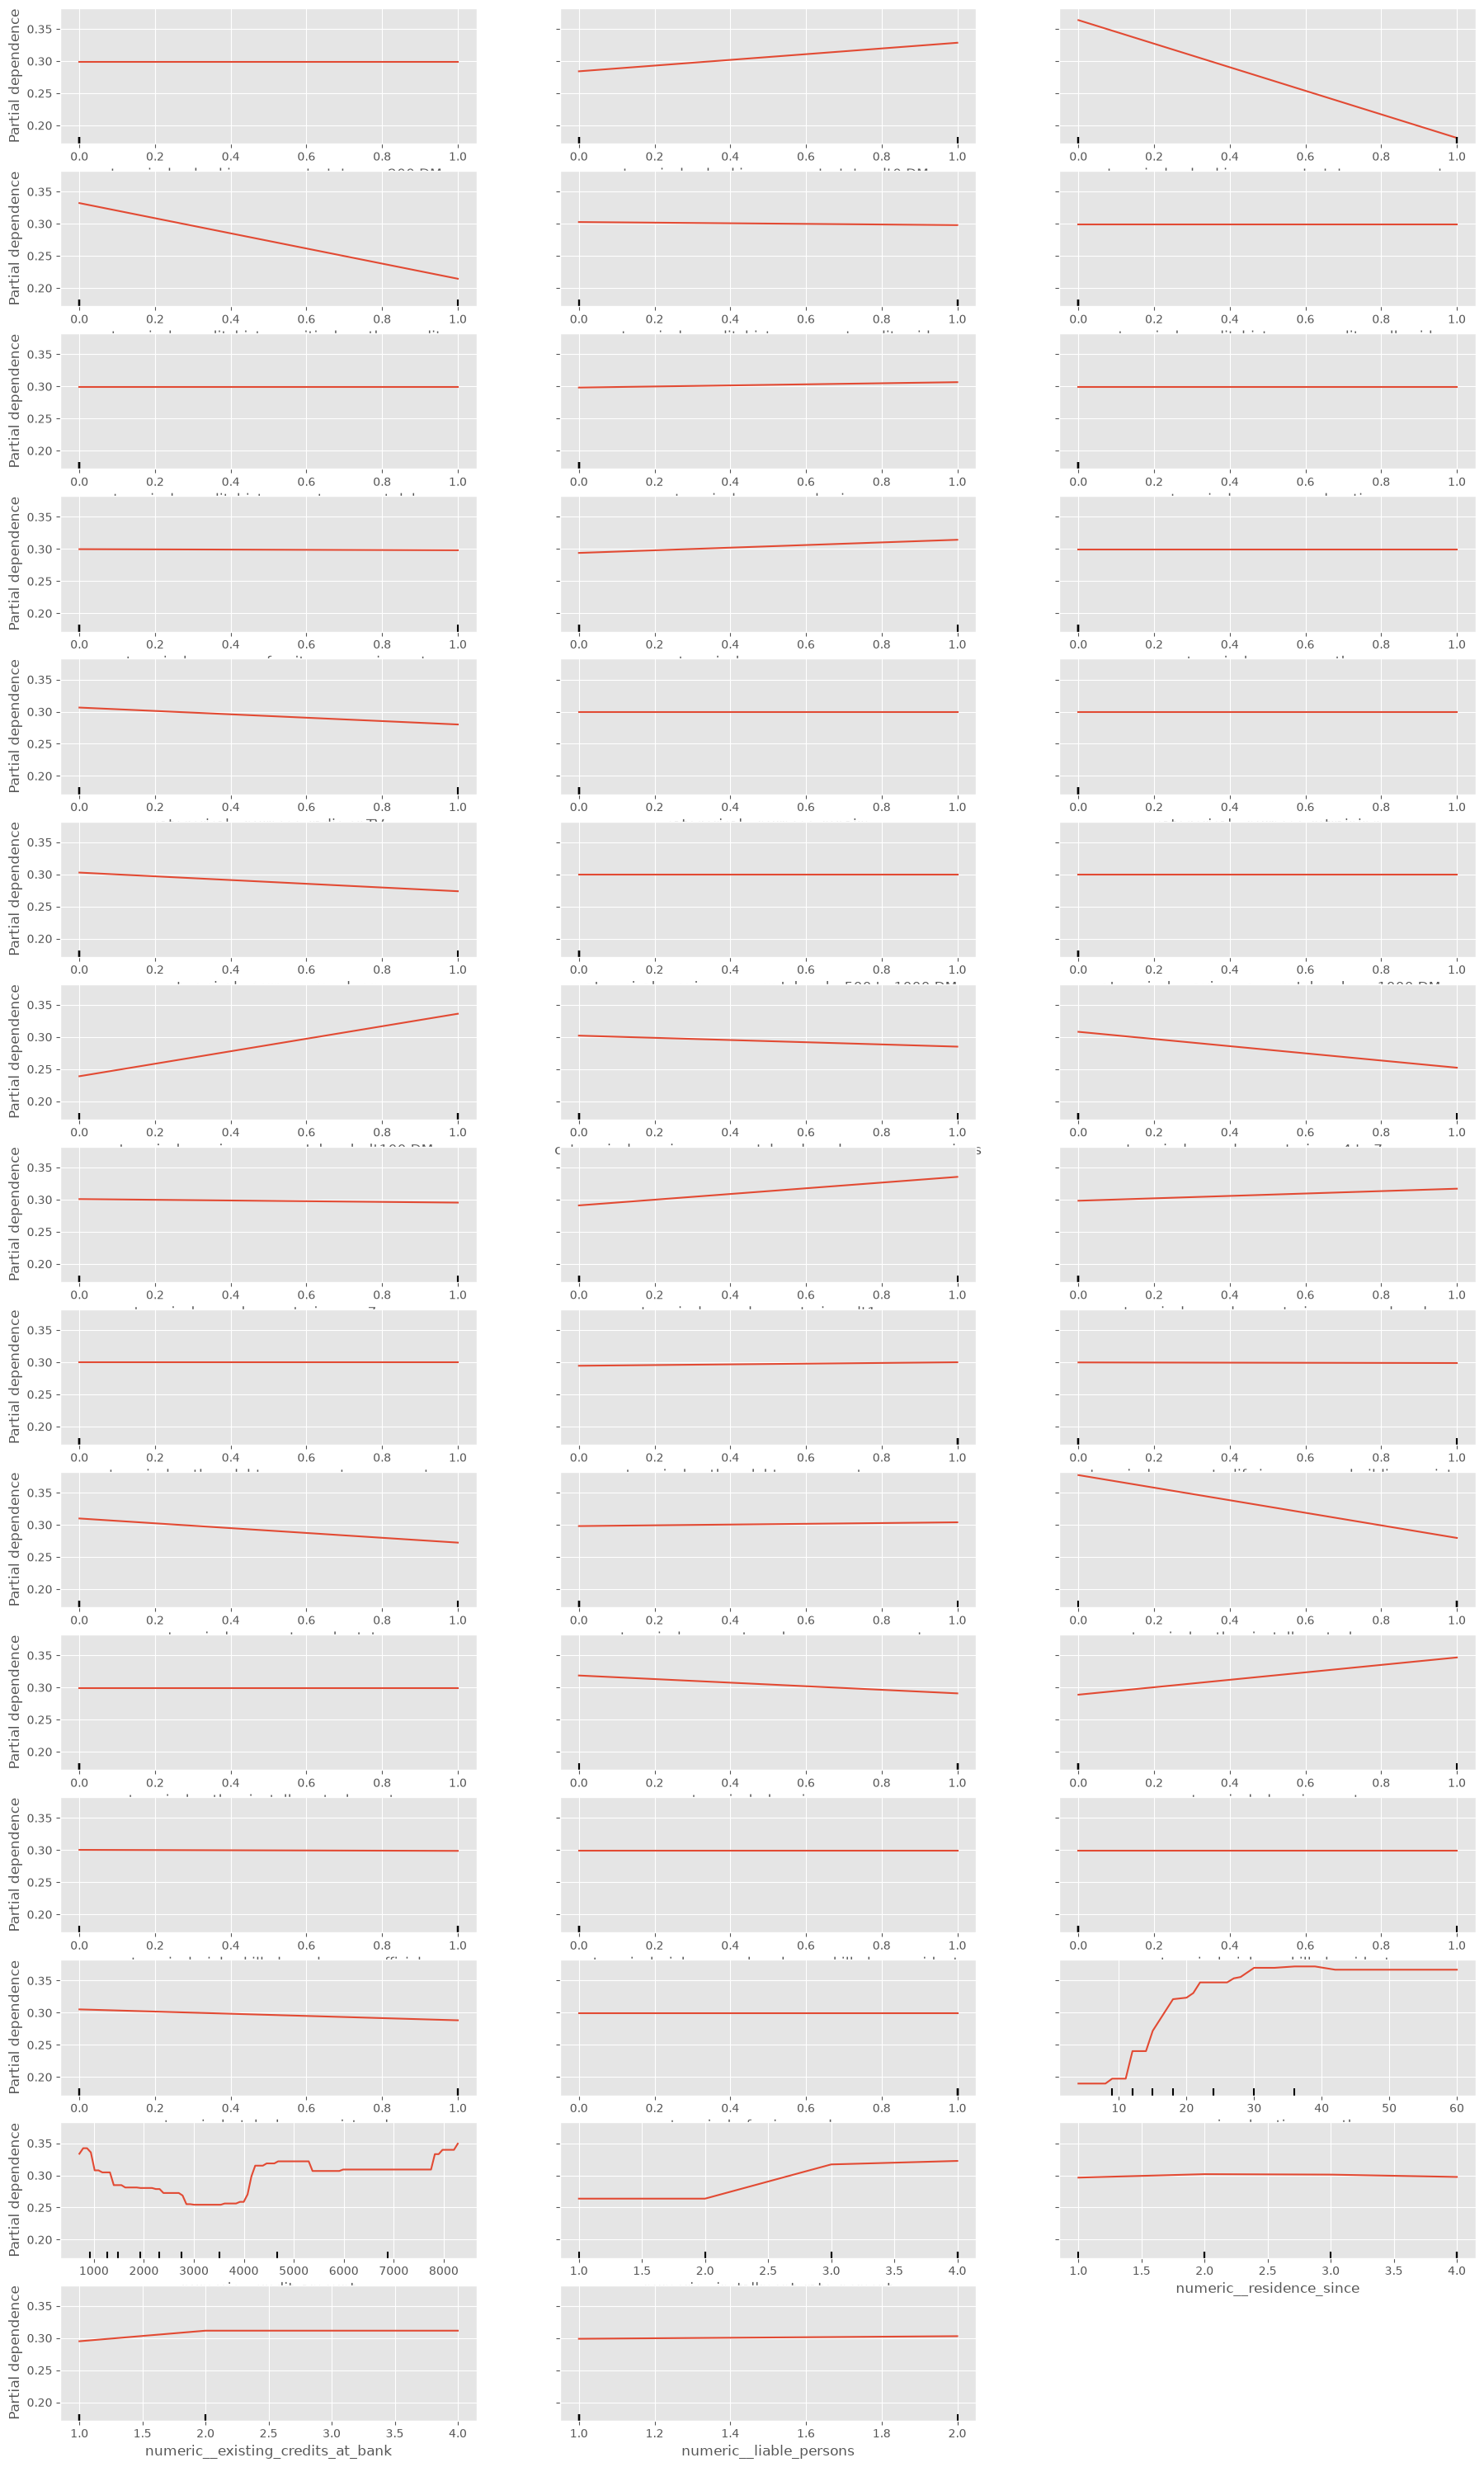

In [28]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X_oh_train,
    features=X_oh_train.columns,
    n_cols=3
)

n_rows = (len(X.columns) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [29]:
models['xgb raw'] = final_model

In [30]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)